In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
data=pd.read_csv(r"C:\Users\HP\Downloads\PCA\PCA\wine.csv")
data.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [3]:
data.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [4]:
data.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [5]:
data_new=data.drop('Type',axis=1)
data_new

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


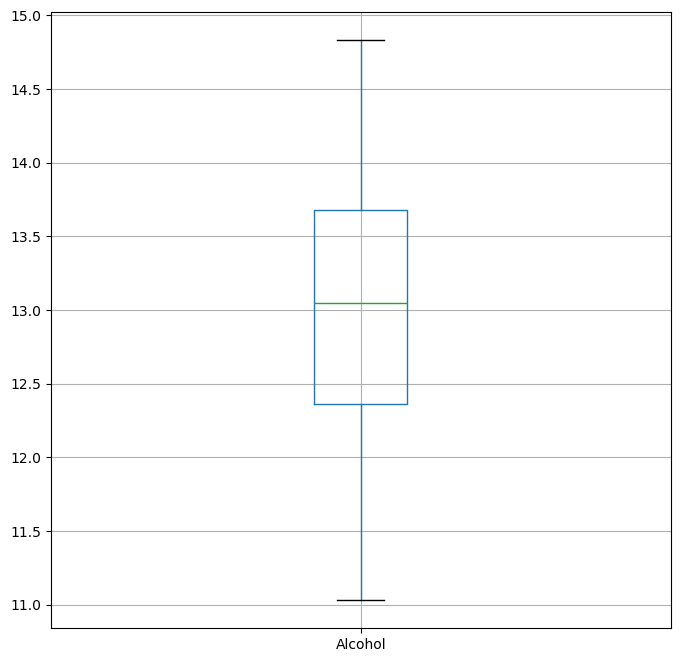

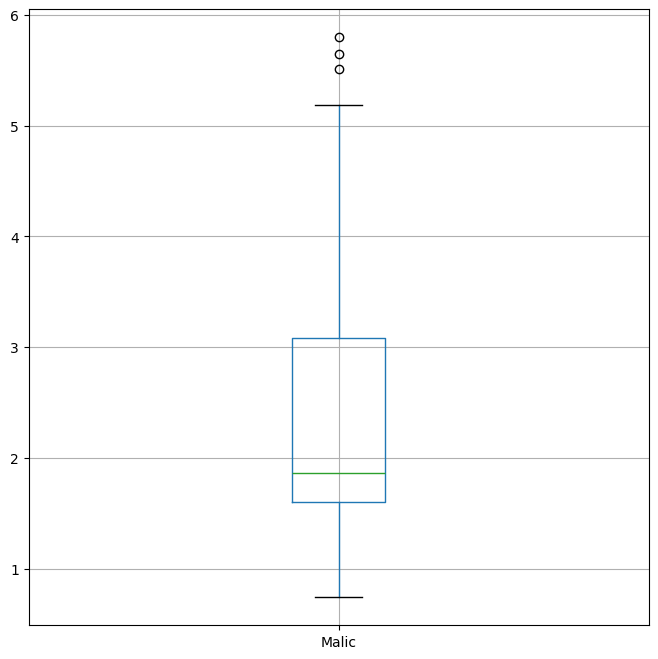

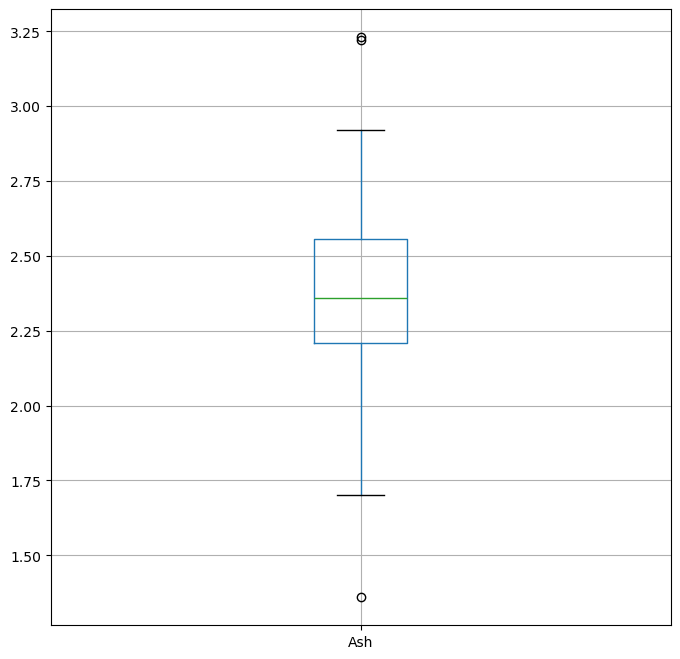

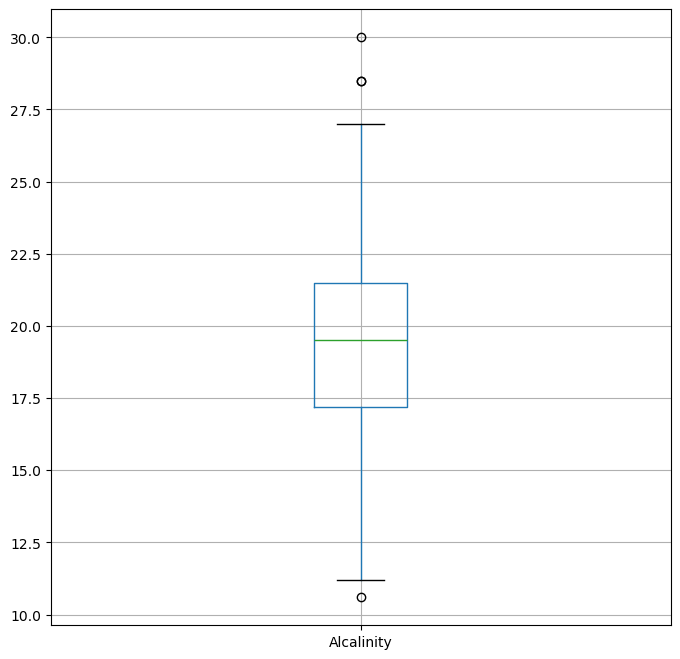

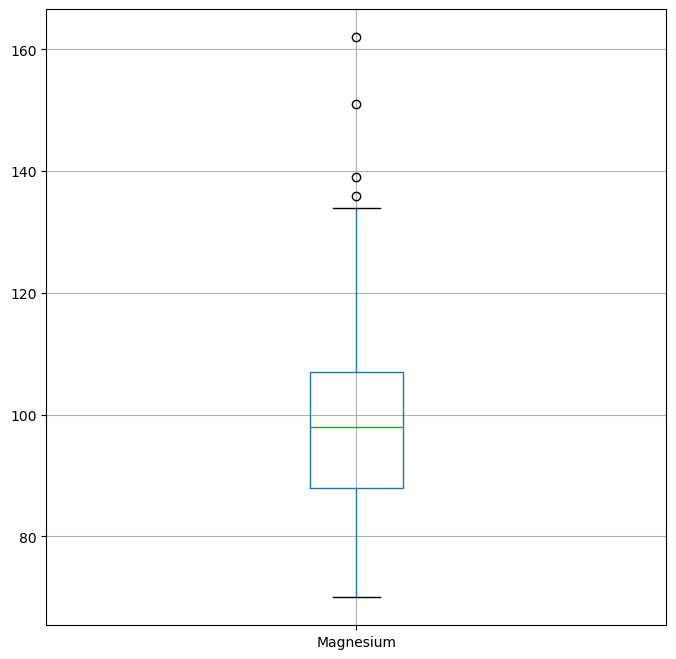

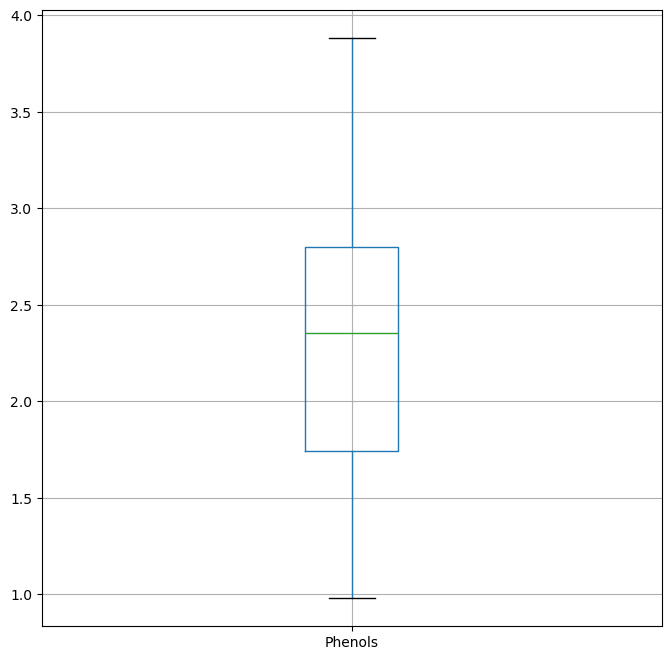

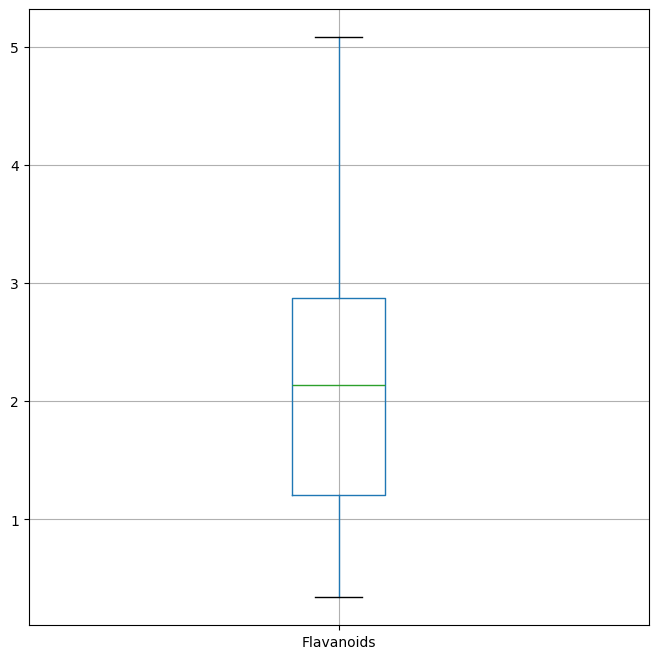

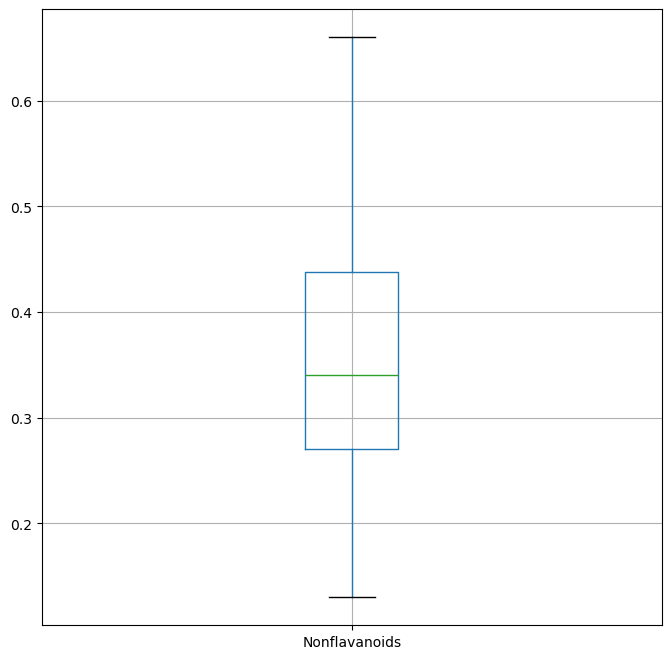

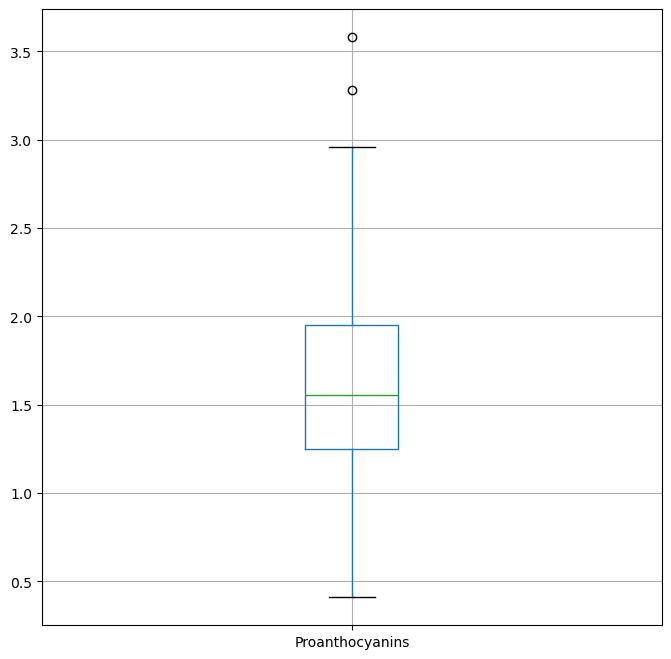

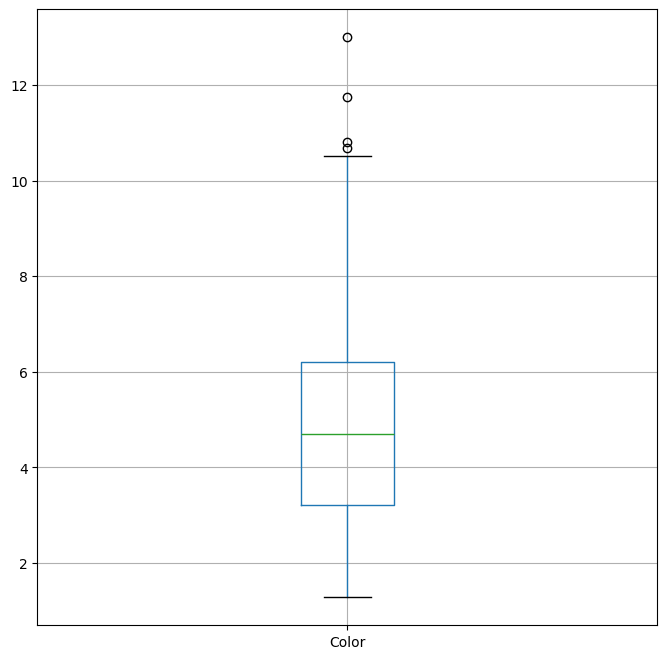

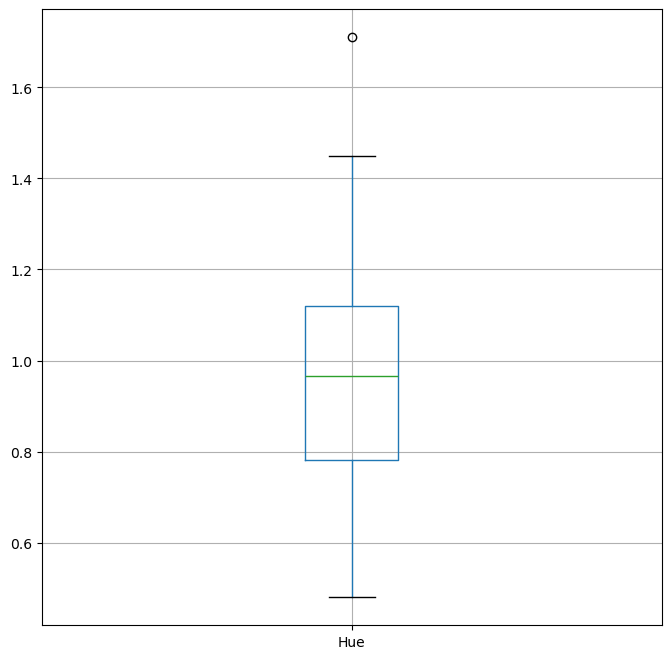

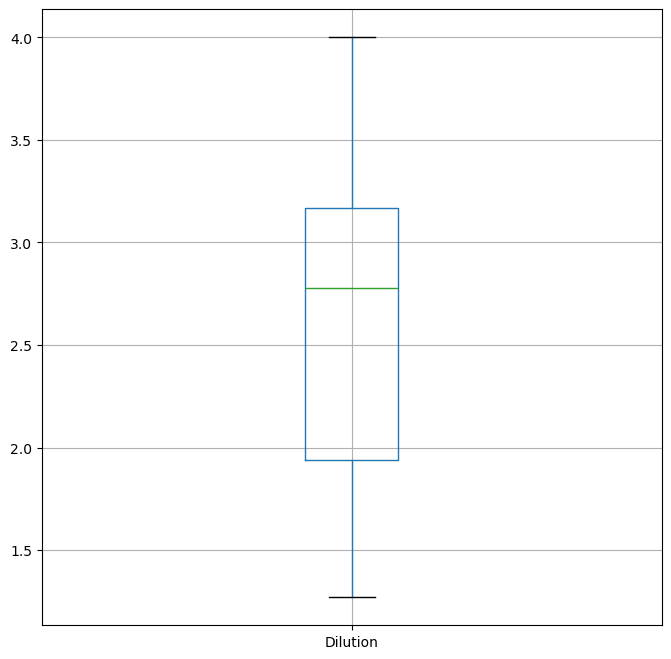

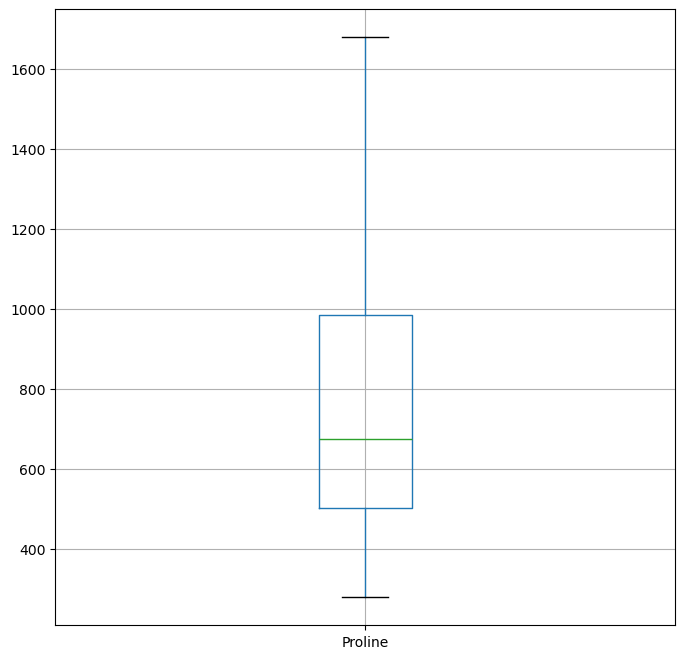

In [6]:
n=len(data_new.columns)
for i in range(0,n):
    plt.figure(figsize=[8,8])
    data.boxplot(column=[data_new.columns[i]])
    plt.show()

In [7]:
def remove_outlier(col):
    Q1,Q3=col.quantile([0.25,0.75])
    IQR=Q3-Q1
    lower_range=Q1-(1.5*IQR)
    upper_range=Q3+(1.5*IQR)
    return lower_range,upper_range

In [8]:
print(data.shape)
lr_malic,ur_malic=remove_outlier(data_new['Malic'])
data_new['Malic']=np.where(data_new['Malic']>ur_malic,ur_malic,data_new['Malic'])
data_new['Malic']=np.where(data_new['Malic']<lr_malic,lr_malic,data_new['Malic'])
print(lr_malic)
print(ur_malic)

lr_ash,ur_ash=remove_outlier(data_new['Ash'])
data_new['Ash']=np.where(data_new['Ash']>ur_ash,ur_ash,data_new['Ash'])
data_new['Ash']=np.where(data_new['Ash']<lr_ash,lr_ash,data_new['Ash'])
print(lr_ash)
print(ur_ash)

lr_alcalinity,ur_alcalinity=remove_outlier(data_new['Alcalinity'])
data_new['Alcalinity']=np.where(data_new['Alcalinity']>ur_alcalinity,ur_alcalinity,data_new['Alcalinity'])
data_new['Alcalinity']=np.where(data_new['Alcalinity']<lr_alcalinity,lr_alcalinity,data_new['Alcalinity'])

lr_mag,ur_mag=remove_outlier(data_new['Magnesium'])
data_new['Magnesium']=np.where(data_new['Magnesium']>ur_mag,ur_mag,data_new['Magnesium'])
data_new['Magnesium']=np.where(data_new['Magnesium']<lr_mag,lr_mag,data_new['Magnesium'])

lr_proan,ur_proan=remove_outlier(data_new['Proanthocyanins'])
data_new['Proanthocyanins']=np.where(data_new['Proanthocyanins']>ur_proan,ur_proan,data_new['Proanthocyanins'])
data_new['Proanthocyanins']=np.where(data_new['Proanthocyanins']<lr_proan,lr_proan,data_new['Proanthocyanins'])

lr_color,ur_color=remove_outlier(data_new['Color'])
data_new['Color']=np.where(data_new['Color']>ur_color,ur_color,data_new['Color'])
data_new['Color']=np.where(data_new['Color']<lr_color,lr_color,data_new['Color'])

lr_hue,ur_hue=remove_outlier(data_new['Hue'])
data_new['Hue']=np.where(data_new['Hue']>ur_hue,ur_hue,data_new['Hue'])
data_new['Hue']=np.where(data_new['Hue']<lr_hue,lr_hue,data_new['Hue'])

#for j in range(0,n):
    #lr_range,ur_range=remove_outlier(data[data.columns[j]])
    #if np.where(data[data.columns[j]]>ur_range) or np.where(data[data.columns[j]]<lr_range):
        #data[data.columns[j]]=np.where(data[data.columns[j]]>ur_range,ur_range,data[data.columns[j]])
        #data[data.columns[j]]=np.where(data[data.columns[j]]<lr_range,lr_range,data[data.columns[j]])
        #lr_range,ur_range=(0,0)
        #print(data[data.columns[j]])
print(data.shape)


(178, 14)
-0.6174999999999997
5.3025
1.6887499999999998
3.0787500000000003
(178, 14)


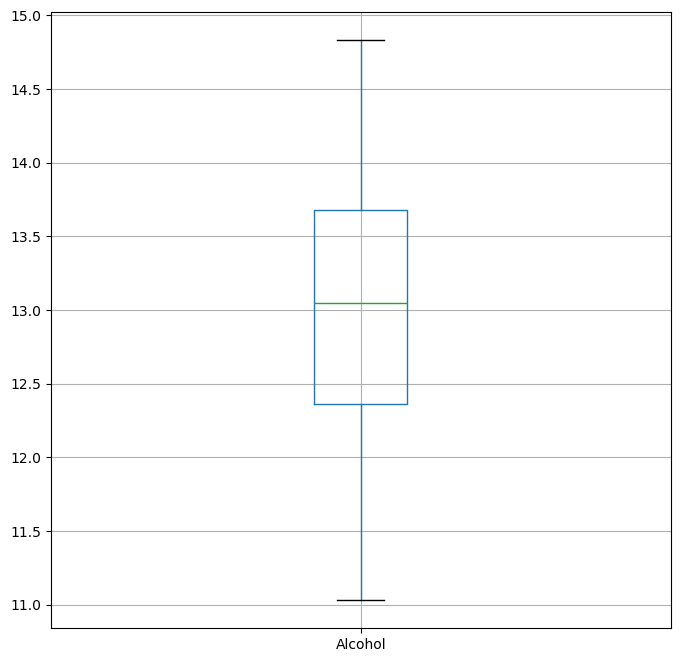

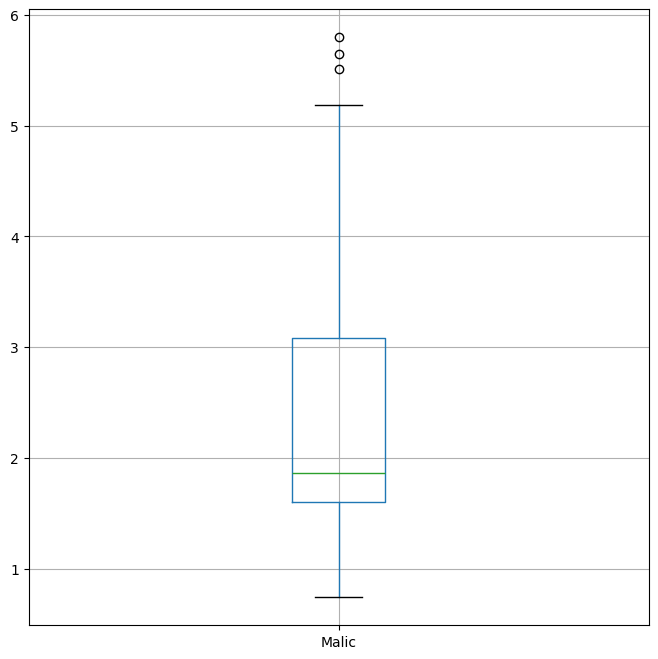

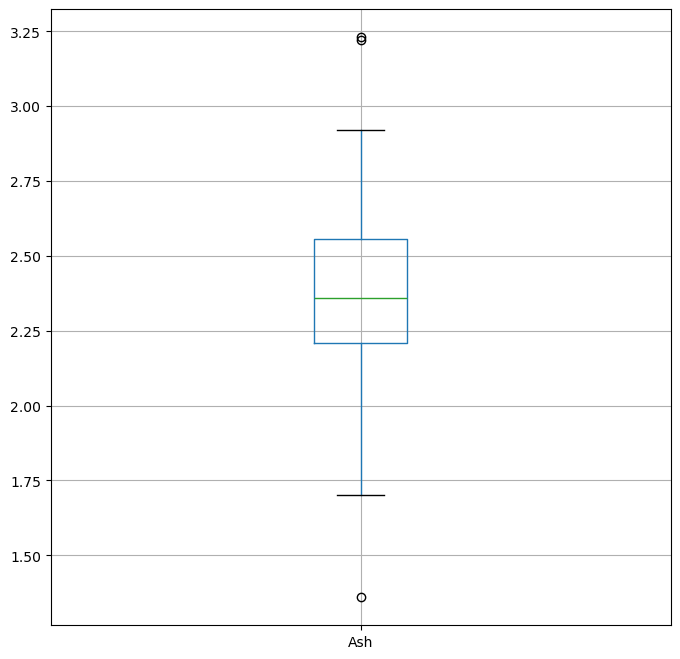

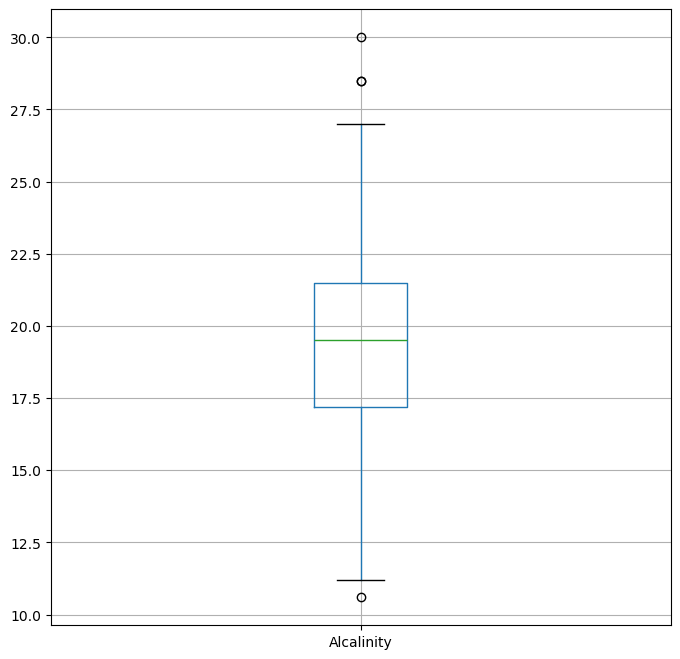

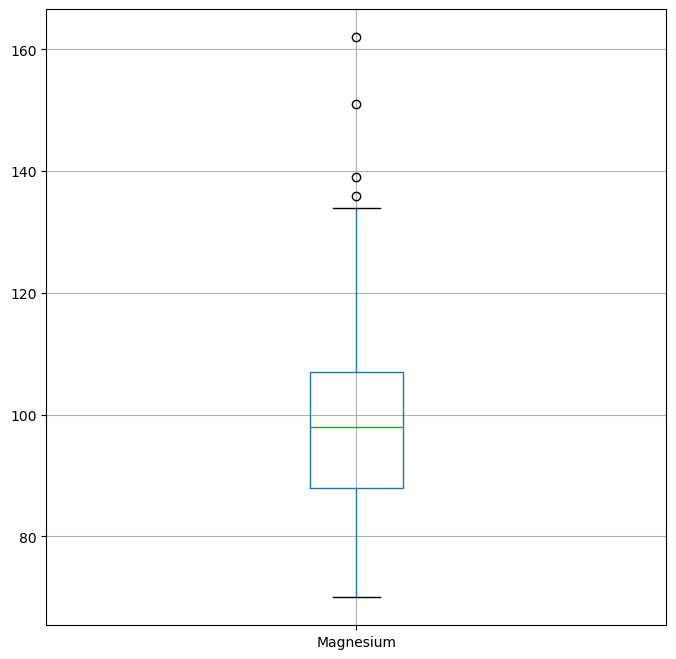

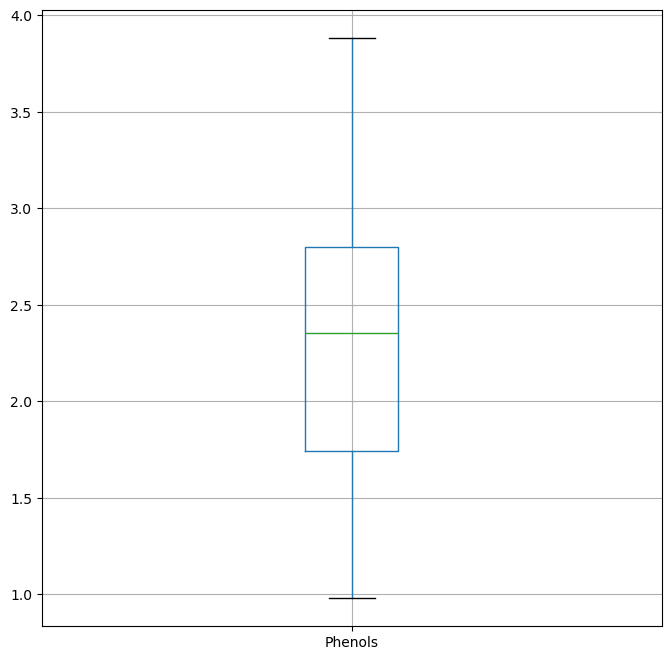

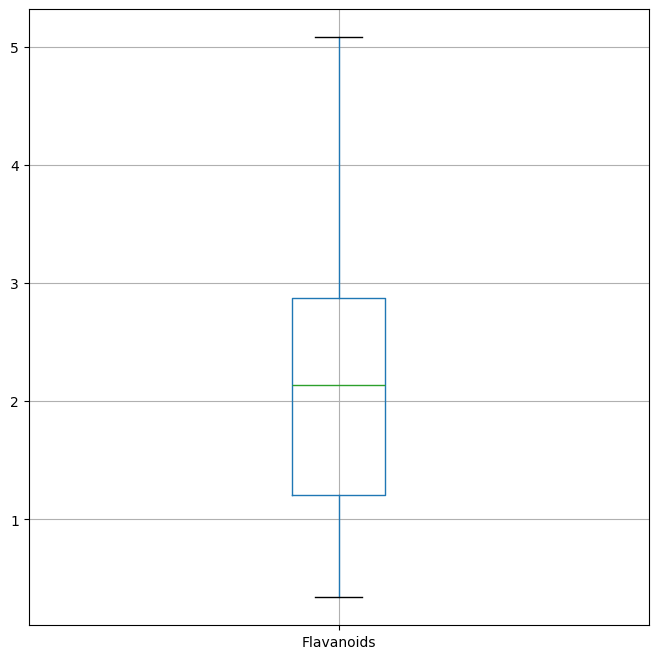

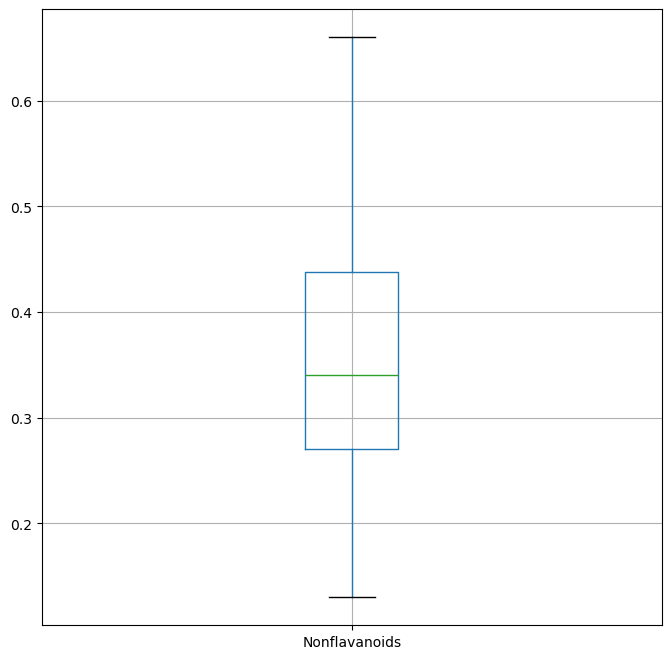

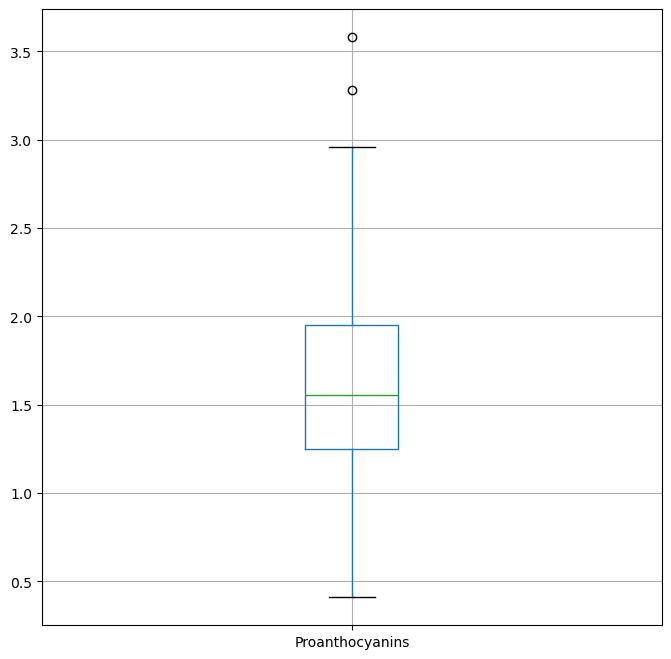

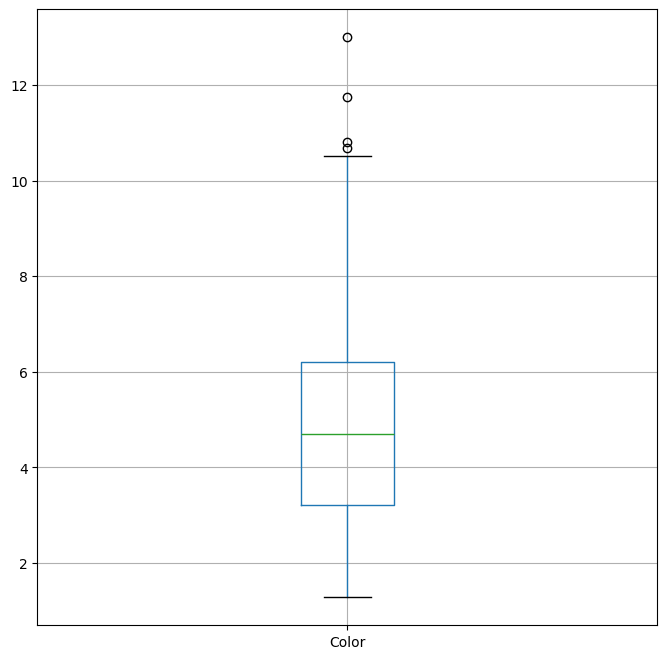

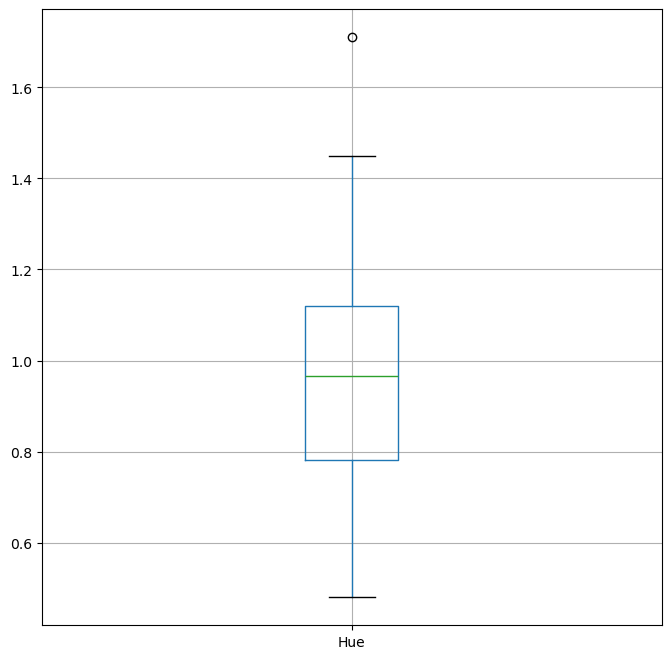

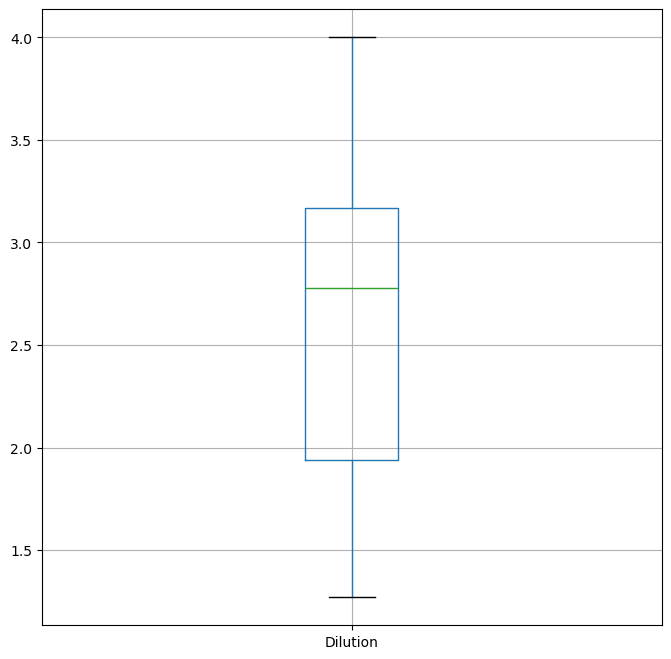

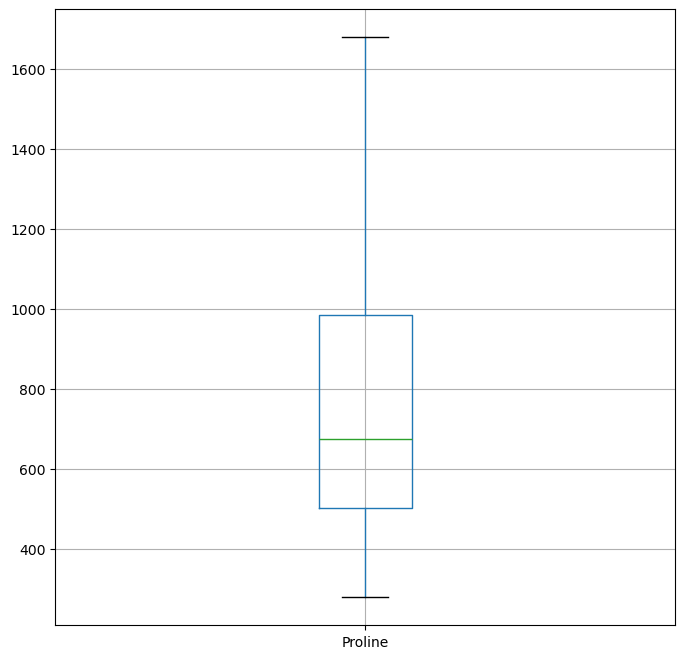

In [9]:
n=len(data_new.columns)
for i in range(0,n):
    plt.figure(figsize=[8,8])
    data.boxplot(column=[data_new.columns[i]])
    plt.show()

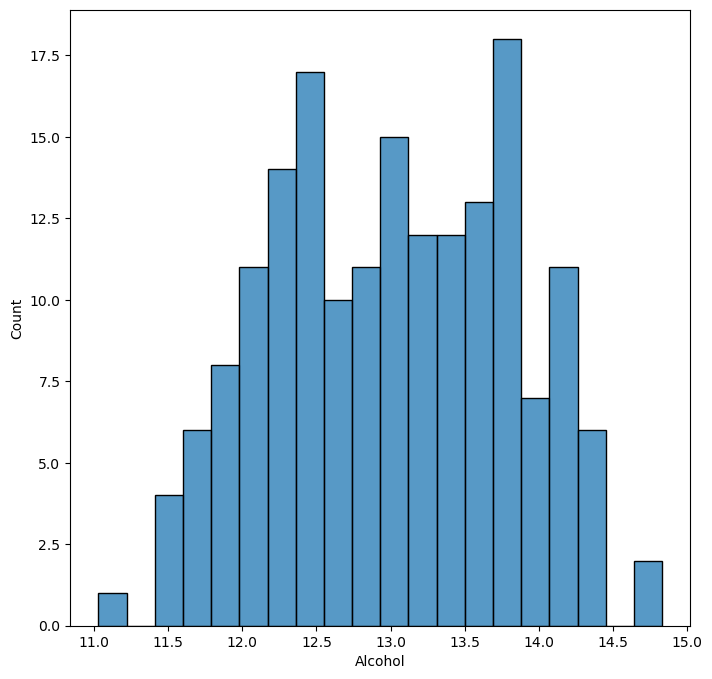

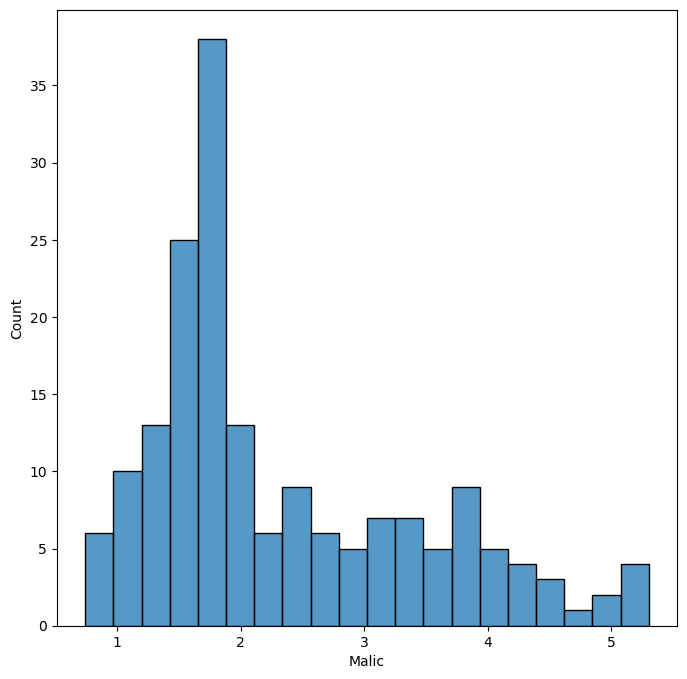

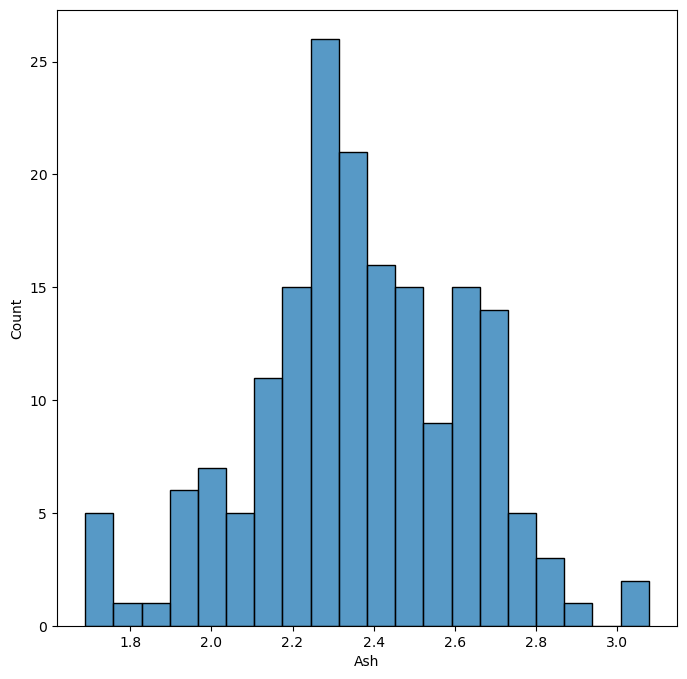

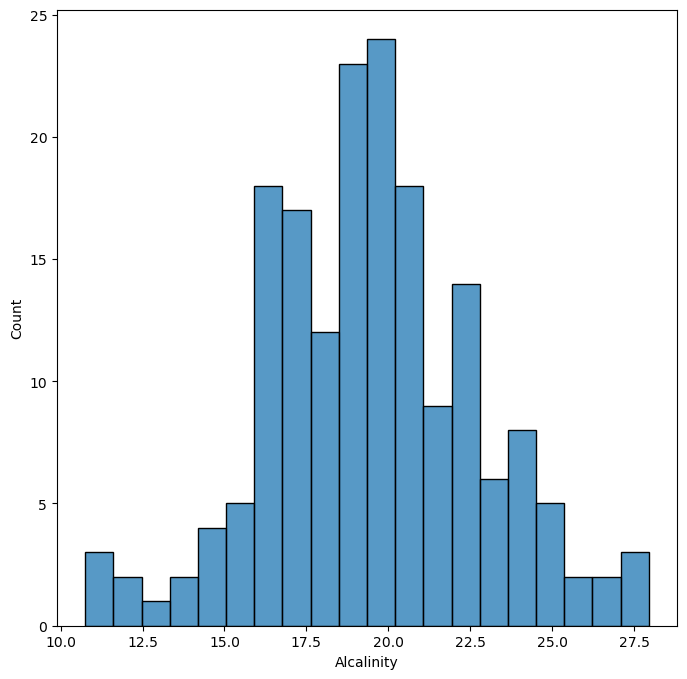

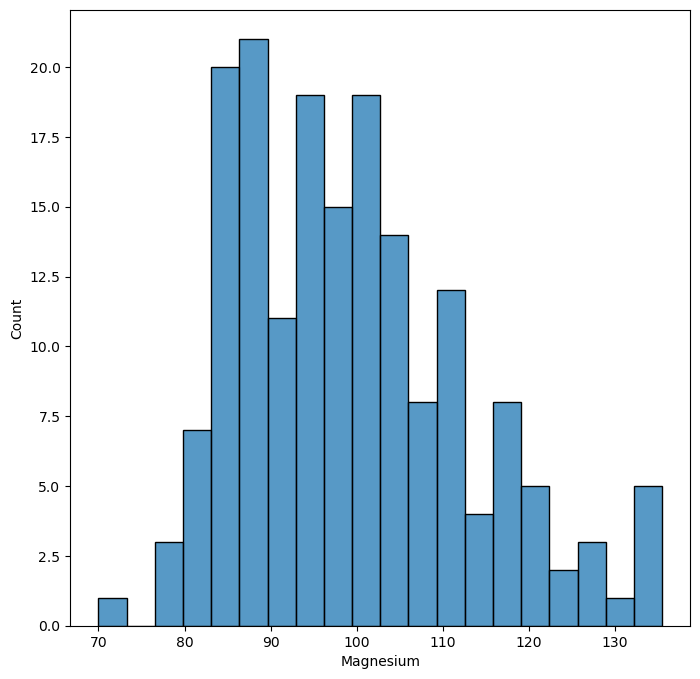

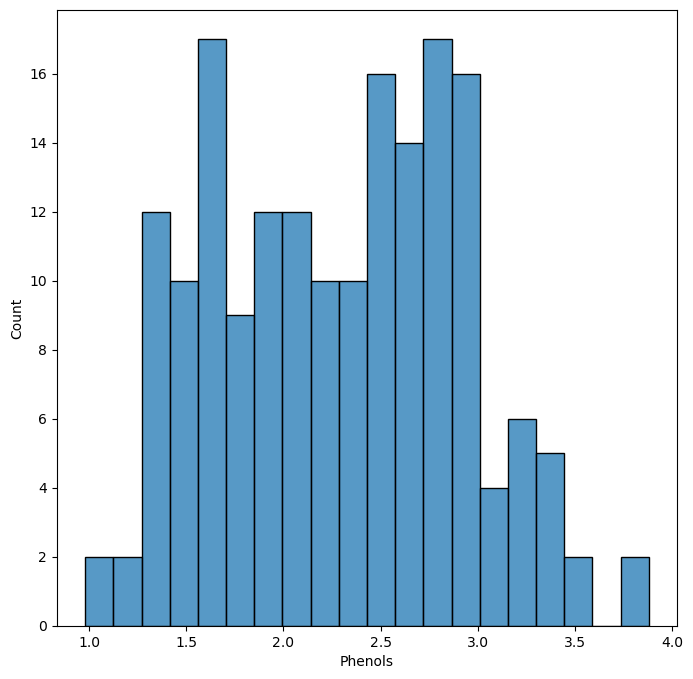

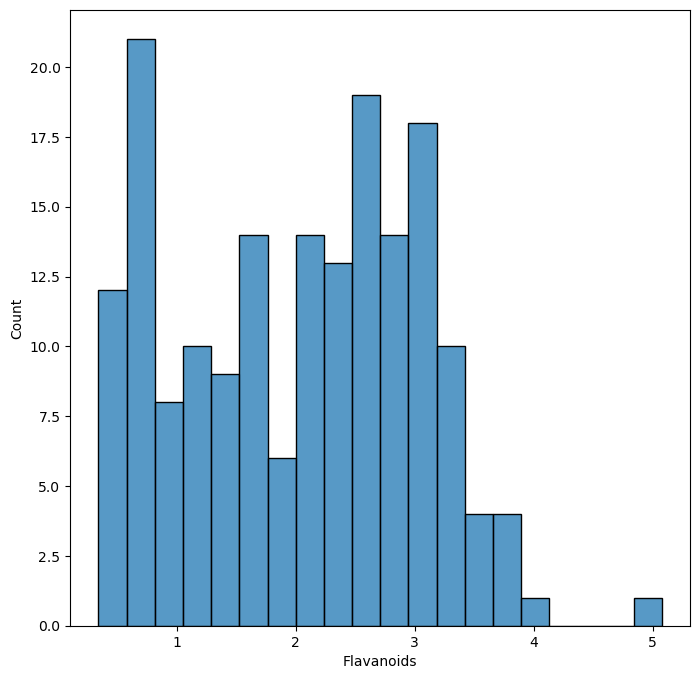

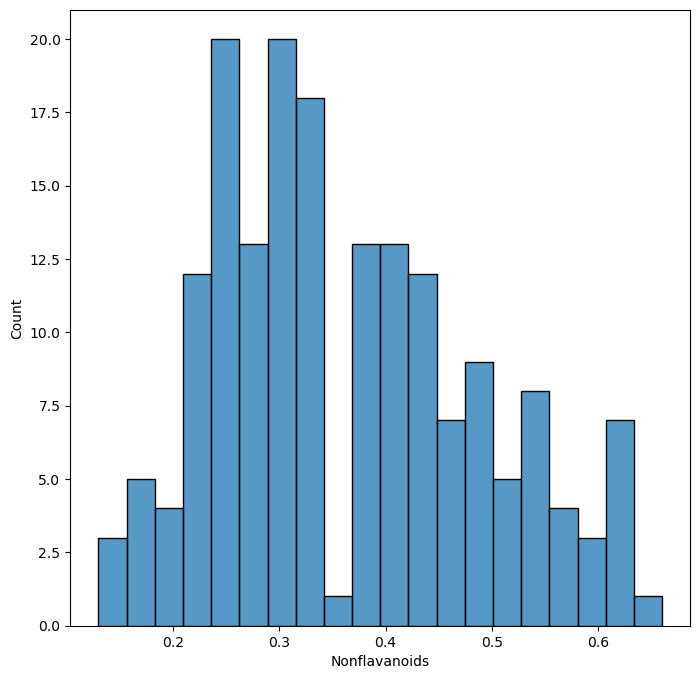

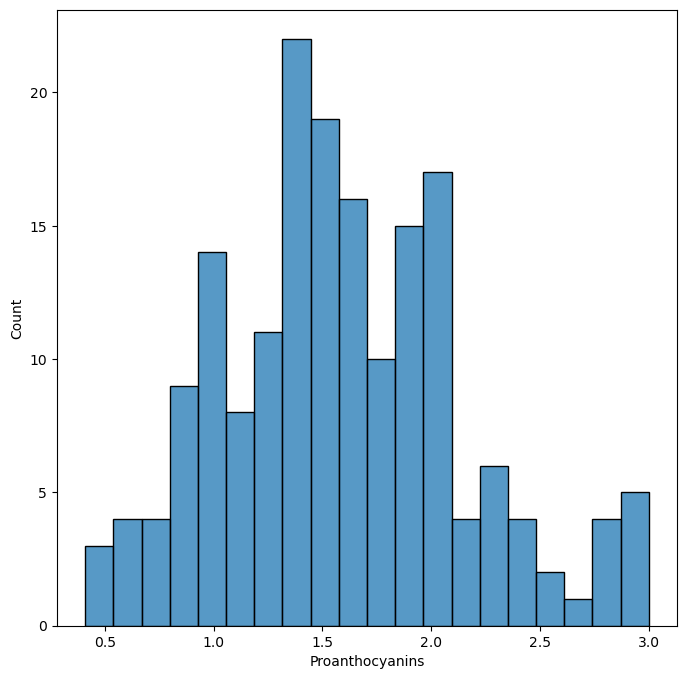

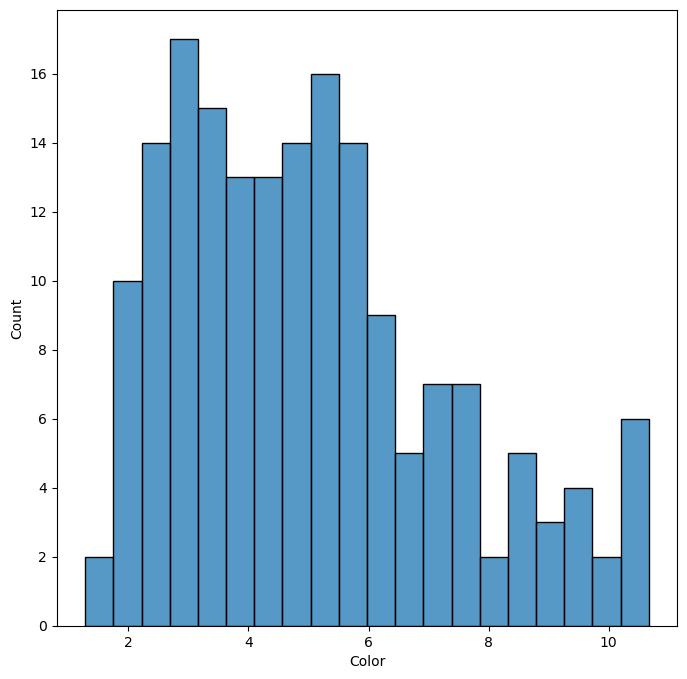

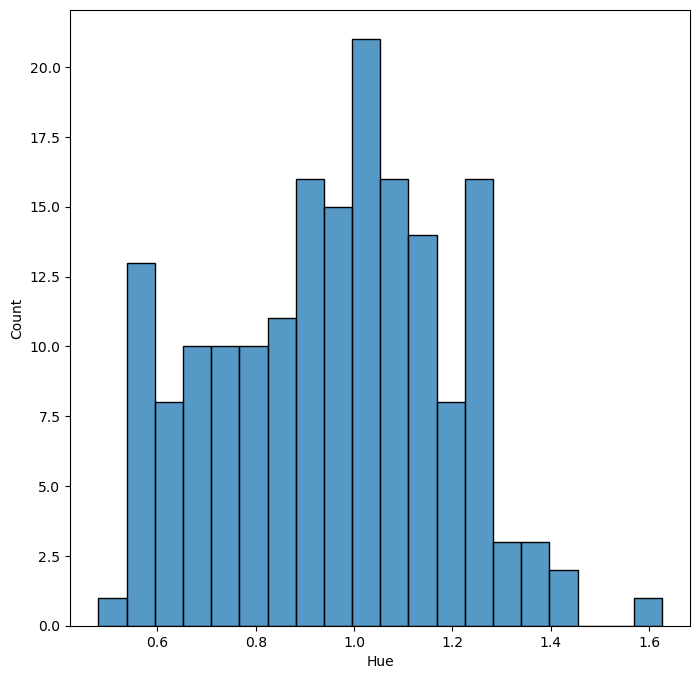

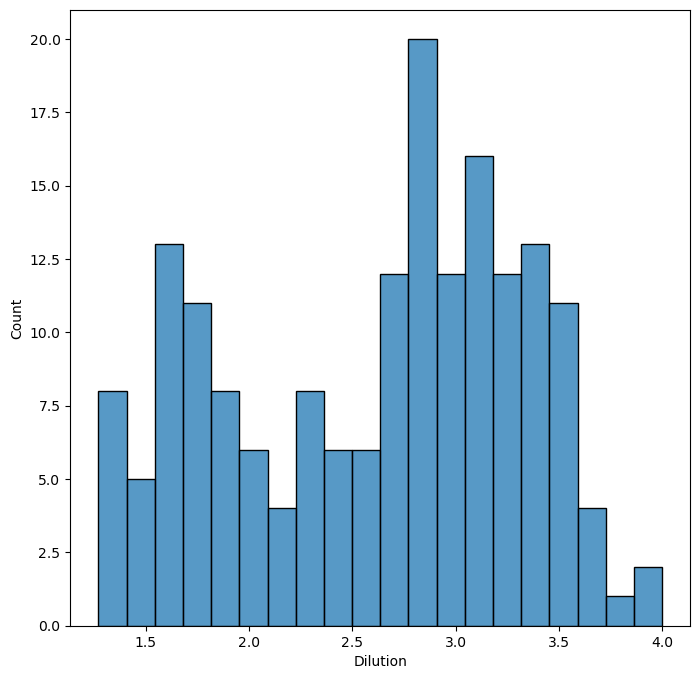

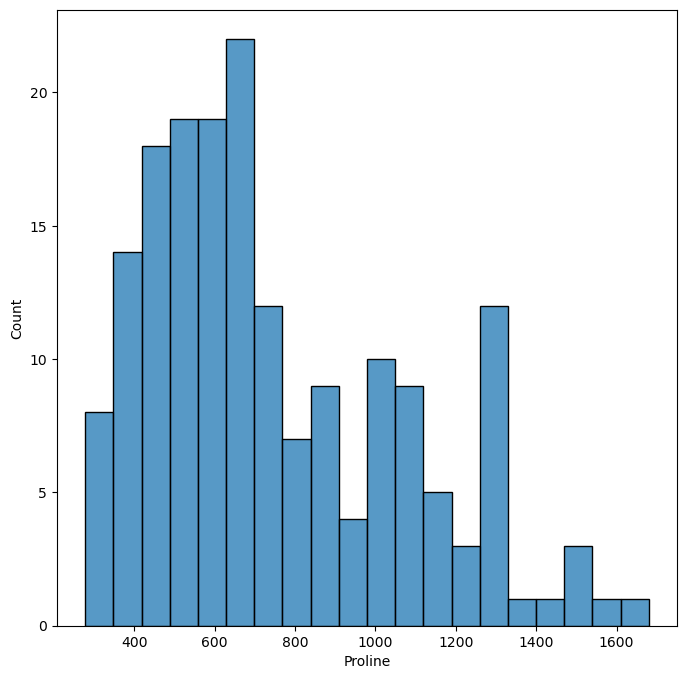

In [10]:
n=len(data_new.columns)
for i in range(0,n):
    plt.figure(figsize=[8,8])
    sns.histplot(data_new[data_new.columns[i]], bins=20)
    plt.show()

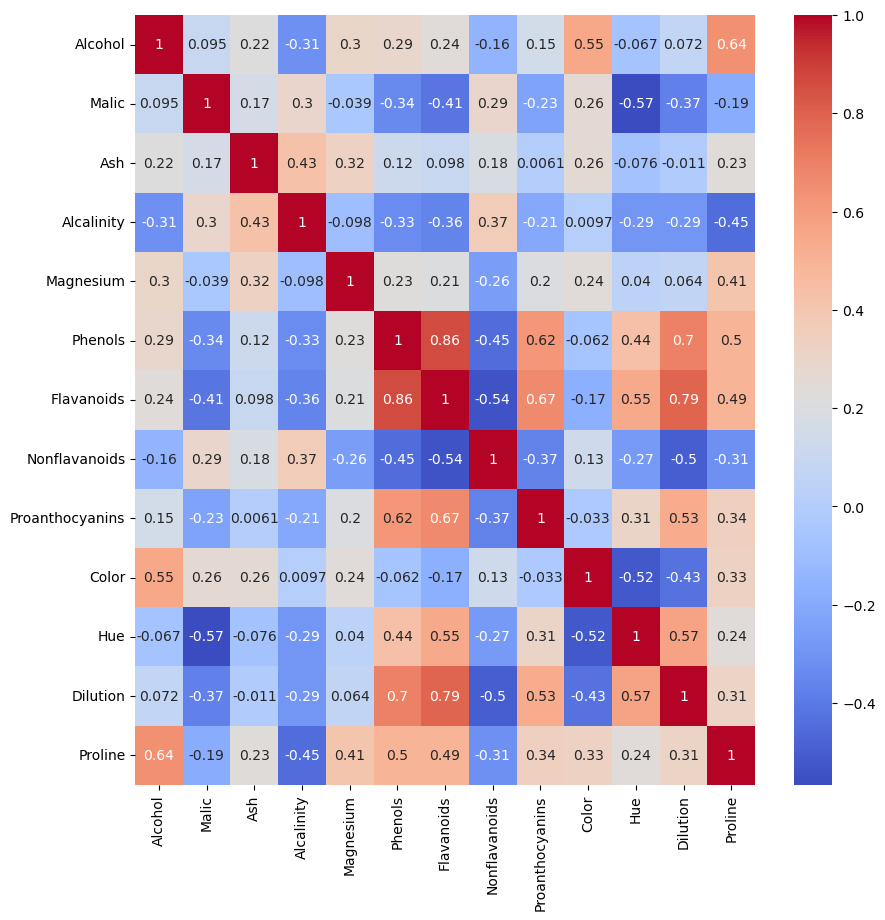

In [11]:
plt.figure(figsize=[10,10])
sns.heatmap(data_new.corr(),annot=True,cmap='coolwarm')
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data_new)
scaled_data

array([[ 1.51861254, -0.56553422,  0.24064008, ...,  0.36660959,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.50172839, -0.86217567, ...,  0.41076822,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02694849,  1.15331518, ...,  0.32245097,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.77705125, -0.40583812, ..., -1.6205284 ,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.23659622,  0.0124713 , ..., -1.57636978,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.61297912,  1.41951209, ..., -1.53221115,
        -1.42894777, -0.59516041]], shape=(178, 13))

In [13]:
from sklearn.decomposition import PCA
pca=PCA()
pca_values=pca.fit(scaled_data)
var = pca.explained_variance_ratio_
cum_var = np.cumsum(var)

print(f"Variance explained by first two components: {cum_var[1]}%")

Variance explained by first two components: 0.5608557742813387%


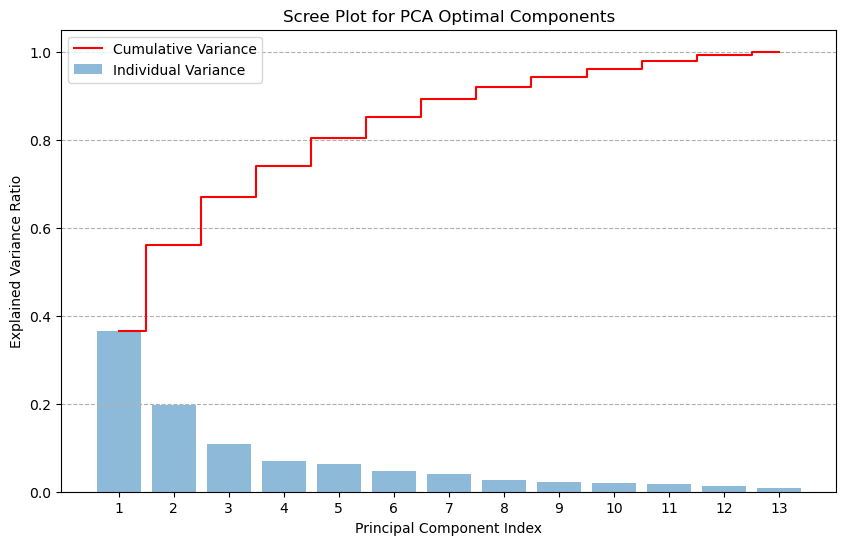

In [14]:
plt.figure(figsize=(10, 6))

# Individual Variance (Bars)
plt.bar(range(1, len(var) + 1), var, alpha=0.5, align='center', label='Individual Variance')

# Cumulative Variance (Line/Step)
plt.step(range(1, len(cum_var) + 1), cum_var, where='mid', label='Cumulative Variance', color='red')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot for PCA Optimal Components')
plt.legend(loc='best')
plt.xticks(range(1, len(var) + 1))
plt.grid(axis='y', linestyle='--')
plt.show()

In [15]:
#from the above scree plot, we can conclude the optimal no: of components is 3

In [16]:
pca_optimal=PCA(n_components=3)
pca_features=pca_optimal.fit_transform(scaled_data)
pca_df=pd.DataFrame(data=pca_features,columns=['PC1', 'PC2', 'PC3'])
pca_df.head()  

,PC1,PC2,PC3
0,3.358147,1.520222,-0.126375
1,2.229215,-0.333261,-2.042838
2,2.540057,1.036953,1.018845
3,3.781124,2.782566,-0.149224
4,1.016872,0.955225,2.113169


In [17]:
from sklearn.cluster import KMeans
kmeans_model=KMeans(n_clusters=3,init='k-means++',random_state=42)
kmeans_cluster_labels=kmeans_model.fit_predict(scaled_data)
print(kmeans_cluster_labels)
kmeans_df=pd.DataFrame()
kmeans_df['Cluster ID']=kmeans_cluster_labels
kmeans_df

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


,Cluster ID
0,2
1,2
2,2
3,2
4,2
...,...
173,1
174,1
175,1
176,1


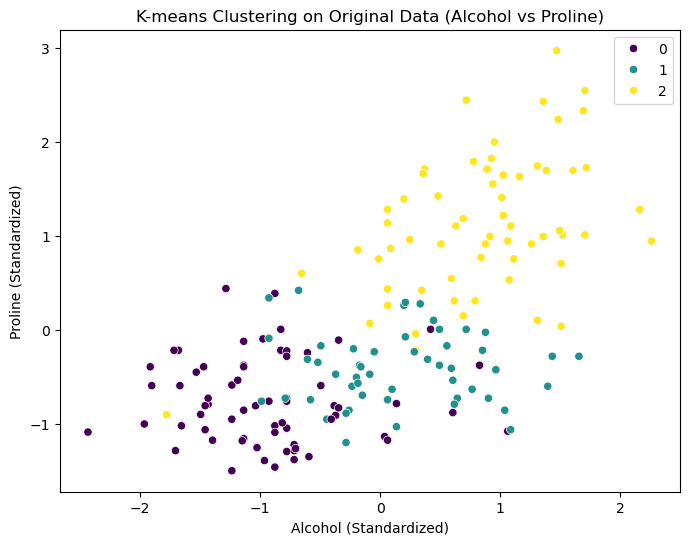

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=scaled_data[:, 0], y=scaled_data[:, 12], hue=kmeans_cluster_labels, palette='viridis')
plt.title('K-means Clustering on Original Data (Alcohol vs Proline)')
plt.xlabel('Alcohol (Standardized)')
plt.ylabel('Proline (Standardized)')
plt.show()

In [19]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate metrics
sil_score = silhouette_score(scaled_data, kmeans_cluster_labels)
db_index = davies_bouldin_score(scaled_data, kmeans_cluster_labels)

print(f"Silhouette Score (Original Data): {sil_score:.4f}")
print(f"Davies-Bouldin Index (Original Data): {db_index:.4f}")

Silhouette Score (Original Data): 0.2855
Davies-Bouldin Index (Original Data): 1.3816


In [20]:
pca_model_1=KMeans(n_clusters=3,init='k-means++',random_state=42)
kmeans_pca_labels=pca_model_1.fit_predict(pca_df)
kmeans_df_pca=pd.DataFrame()
kmeans_df_pca['PCA Cluster ID']=kmeans_pca_labels
kmeans_df_pca

,PCA Cluster ID
0,2
1,2
2,2
3,2
4,2
...,...
173,1
174,1
175,1
176,1


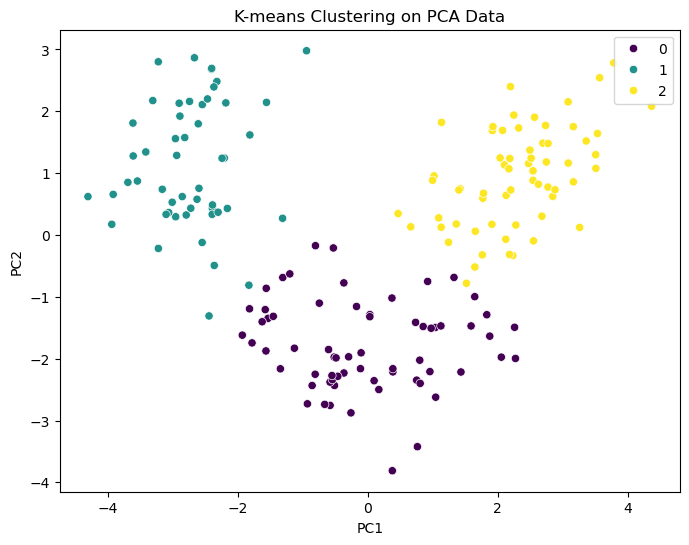

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=kmeans_pca_labels, palette='viridis')
plt.title('K-means Clustering on PCA Data')
plt.show()

In [22]:
sil_score_pca = silhouette_score(pca_df, kmeans_pca_labels)
db_index_pca = davies_bouldin_score(pca_df, kmeans_pca_labels)

print(f"Silhouette Score : {sil_score_pca:.4f}")
print(f"Davies-Bouldin Index : {db_index_pca:.4f}")

Silhouette Score : 0.4537
Davies-Bouldin Index : 0.8382
